In [ ]:
from more_itertools import chunked
import cv2
import re
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
from natsort import natsorted
import glob
from aniposelib.boards import CharucoBoard, Checkerboard
from aniposelib.cameras import Camera, CameraGroup
from aniposelib.utils import load_pose2d_fnames

In [ ]:

print("OpenCV version: ", cv2.__version__)

def get_position(file):
    print("Processing file: ", file)
    pattern = re.compile(r'(\d+)_charuco.mp4')
    cam_id = int(pattern.search(file).group(1))

    # read video
    cap = cv2.VideoCapture(file)
    backSub = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=100)

    n_frames = 0
    x = []
    y = []
    frames = []

    # loop over frames
    while True:

        ret, frame = cap.read()
        if not ret:
            break
        
        # apply background subtraction
        fgMask = backSub.apply(frame)

        # get contours
        contours, hierarchy = cv2.findContours(fgMask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        # initialize cx, cy
        cx, cy = np.nan, np.nan

        # and check for contours
        if len(contours) != 0:
            
            # find the biggest area
            c = max(contours, key = cv2.contourArea)
            
            # get the moments
            M = cv2.moments(c)
            
            # get the centroid
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
        x.append(cx)
        y.append(cy)
        frames.append(n_frames)

        n_frames += 1

    cap.release()
    df = pd.DataFrame(columns=['frame_num', 'file_num', 'obj_id', 'cam_id', 'x', 'y'])
    df['cam_id'] = np.repeat(cam_id, len(frames))
    df['frame_num'] = frames
    df['x'] = x
    df['y'] = y
    return df


videos_folder = '/mnt/nfc3008_videos/calibration_20230626/'
video_files = natsorted(glob.glob(videos_folder + '*.mp4'))

all_dfs = []
for files in chunked(video_files, 4):
    print("Looping over file group: ", files)
    
    for file in files:
        df = get_position(file)
        all_dfs.append(df)

full_df = pd.concat(all_dfs)

In [ ]:
cgroup = CameraGroup.load('/mnt/nfc3008_videos/calibration_20230621/calibration.toml')
cam_names = ['23088882', '23088879', '23096298', '23047980']

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()

points_flat = np.zeros((4, int(len(full_df)/4), 2))

for i, cam in enumerate(cam_names):

    pos = full_df[full_df["cam_id"] == int(cam)][['x','y']].values
    points_flat[i, :, :] = pos

    p3ds_flat = cgroup.triangulate(points_flat, progress=True)
    reprojection_errors = cgroup.reprojection_error(p3ds_flat, points_flat, mean=True)



In [ ]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(p3ds_flat[:, 0], p3ds_flat[:, 1], p3ds_flat[:, 2])
plt.show()

In [120]:
arrays = []
start_idx = 0
for i in range(len(p3ds_flat)-1):
    a = p3ds_flat[i, :]
    b = p3ds_flat[i+1, :]

    if np.isnan(a).any(axis=0) and ~np.isnan(b).any(axis=0):
        start_idx = i+1
        continue

    if ~np.isnan(a).any(axis=0) and np.isnan(b).any(axis=0):
        end_idx = i+1
        arrays.append(p3ds_flat[start_idx:end_idx, :])
        continue

In [130]:
from scipy.signal import savgol_filter
headings = []
for arr in arrays:
    if len(arr) < 100:
        continue
    smooth_arr = savgol_filter(arr, 21, 3, axis=0)
    displacement = np.diff(smooth_arr, axis=0)
    heading = np.arctan2(displacement[:, 1], displacement[:, 0])
    headings.append(heading)

IndexError: list index out of range

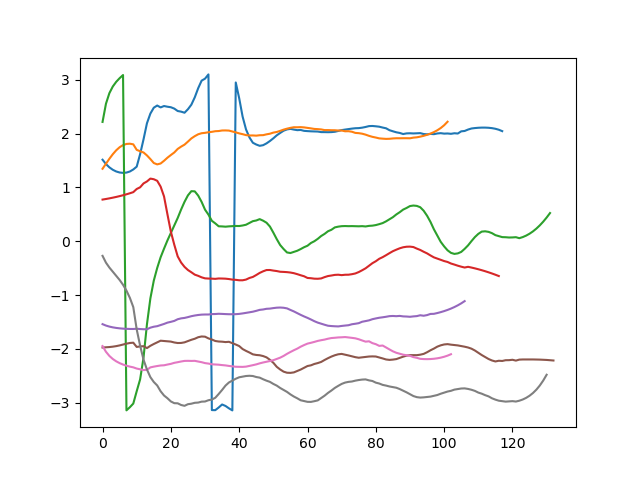

In [135]:
fig = plt.figure()

height = 128
circle_positions = [
    (60, height // 2), (140, height // 2),
    (220, height // 2), (300, height // 2),
    (380, height // 2), (460, height // 2),
    (540, height // 2), (620, height // 2)
]

for i, heading in enumerate(headings):
    plt.plot(heading, label=circle_positions[i])
plt.show()

In [136]:
len(headings)

9